# Transcode BigWig Signal Analysis: Pancreas Fallback

Pancreas-only fallback for the redemption meeting. This notebook scores translon DB features using the grouped pancreas BigWigs only.

Scope:
- six individual pancreas samples plus `Ribo_Pancreas_pooled` if present
- one signal mode at a time, selected by `SIGNAL_MODE`
- stranded BigWigs are linked into `sample.forward.bw` / `sample.reverse.bw` names so the existing scorer can be reused

Default mode is `unique_no_junction`, which is the cleanest conservative signal track for presentation use.


In [47]:
import json
import sqlite3
import sys
from pathlib import Path
import inspect

import matplotlib
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is None:
        matplotlib.use('Agg')
    else:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SCRIPT_DIR = Path.cwd()
if (SCRIPT_DIR / 'transcode_bigwig_signal_scores.py').exists():
    sys.path.insert(0, str(SCRIPT_DIR))
else:
    sys.path.insert(0, str(Path('/Users/jackt/projects/all-RiboSeq/ensembl-genes-nf/pipelines/translon-consensus/scripts')))

import transcode_bigwig_signal_scores as signal_scores

HAS_PYBIGWIG = signal_scores.HAS_PYBIGWIG
ScoreConfig = signal_scores.ScoreConfig
discover_bigwigs = signal_scores.discover_bigwigs
expand_scores_by_tool = signal_scores.expand_scores_by_tool
periodicity_score = signal_scores.periodicity_score
score_database = signal_scores.score_database
uniformity_score = signal_scores.uniformity_score
SCORE_MODULE = Path(signal_scores.__file__).resolve()
SCORER_SUPPORTS_PSITE = (
    hasattr(signal_scores, 'load_psite_offsets')
    and 'psite_offsets' in inspect.signature(score_database).parameters
    and 'psite_offset' in getattr(ScoreConfig, '__dataclass_fields__', {})
)

def load_psite_offsets(path):
    if hasattr(signal_scores, 'load_psite_offsets'):
        return signal_scores.load_psite_offsets(path)
    path = Path(path)
    if not path.exists():
        print(f'P-site offsets file {path} is absent; using offset 0 for all samples')
        return {}
    raw = json.loads(path.read_text())
    offsets = {}
    for sample_id, value in raw.items():
        offset = value.get('offset') if isinstance(value, dict) else value
        offsets[str(sample_id)] = int(offset) % 3
    return offsets

DB = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite')
GROUPED_BIGWIG_ROOT = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/gencode_pilot_pancreas/grouped_pilot_tracks/bigwigs')
OUT_DIR = Path('figures_bigwig_pancreas_fallback')
OUT_DIR.mkdir(exist_ok=True)
GTF = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/gencode.v47.annotation.gtf')
PSITE_OFFSETS = OUT_DIR / 'psite_offsets.json'
SCORES_ARE_REGISTERED = False

PANCREAS_SAMPLES = [
    'SRR11005875_to_79',
    'SRR11005880_to_84',
    'SRR11005885_to_89',
    'SRR11005890_to_94',
    'SRR11005895_to_99',
    'SRR11005900_to_04',
    'Ribo_Pancreas_pooled',
]
SIGNAL_MODES = ['unique_no_junction', 'unique_with_junction', 'multi_no_junction', 'multi_with_junction']
SIGNAL_MODE = 'unique_no_junction'
assert SIGNAL_MODE in SIGNAL_MODES

BIGWIG_ROOT = OUT_DIR / f'bigwig_links_{SIGNAL_MODE}'
BIGWIG_ROOT.mkdir(parents=True, exist_ok=True)

for sample in PANCREAS_SAMPLES:
    for strand in ('forward', 'reverse'):
        src = GROUPED_BIGWIG_ROOT / f'{sample}.{SIGNAL_MODE}.{strand}.bw'
        dst = BIGWIG_ROOT / f'{sample}.{strand}.bw'
        if dst.exists() or dst.is_symlink():
            dst.unlink()
        if src.exists():
            dst.symlink_to(src)

TOOL_ORDER = ['PRICE', 'RiboTIE', 'ORFQuant', 'iRibo', 'RibORF2']
CLS_ORDER = ['cds', 'non_cds']
CLS_LABELS = {'cds': 'CDS', 'non_cds': 'Non-CDS'}
TOOL_COLORS = {
    'PRICE': '#4C72B0',
    'RiboTIE': '#DD8452',
    'ORFQuant': '#55A868',
    'iRibo': '#C44E52',
    'RibORF2': '#8172B2',
}

print(f'pyBigWig available: {HAS_PYBIGWIG}')
print(f'DB path: {DB}')
print(f'DB exists: {DB.exists()}')
print(f'Grouped BigWig root: {GROUPED_BIGWIG_ROOT}')
print(f'Grouped BigWig root exists: {GROUPED_BIGWIG_ROOT.exists()}')
print(f'Signal mode: {SIGNAL_MODE}')
print(f'Scorer BigWig link root: {BIGWIG_ROOT}')
print(f'Output dir: {OUT_DIR.resolve()}')
print(f'Scorer module: {SCORE_MODULE}')
print(f'Scorer supports P-site offsets: {SCORER_SUPPORTS_PSITE}')
if not SCORER_SUPPORTS_PSITE:
    print('Update/sync transcode_bigwig_signal_scores.py before recalculating registered periodicity.')


pyBigWig available: True
DB path: /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite
DB exists: True
Grouped BigWig root: /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/gencode_pilot_pancreas/grouped_pilot_tracks/bigwigs
Grouped BigWig root exists: True
Signal mode: unique_no_junction
Scorer BigWig link root: figures_bigwig_pancreas_fallback/bigwig_links_unique_no_junction
Output dir: /hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/figures_bigwig_pancreas_fallback
Scorer module: /hps/software/users/ensembl/genebuild/jackt/ensembl-genes-nf/pipelines/translon-consensus/scripts/transcode_bigwig_signal_scores.py
Scorer supports P-site offsets: False
Update/sync transcode_bigwig_signal_scores.py before recalculating registered periodicity.


19,225 MANE transcripts with CDS + start codon
bigwig chroms sample: ['GL000194.1', 'GL000208.1', 'GL000216.2']
16,534 transcripts with signal
+ strand dominant frame = f2  ([0.08265498 0.08515472 0.8321903 ])
- strand dominant frame = f2  ([0.0822063  0.08590406 0.83188964])


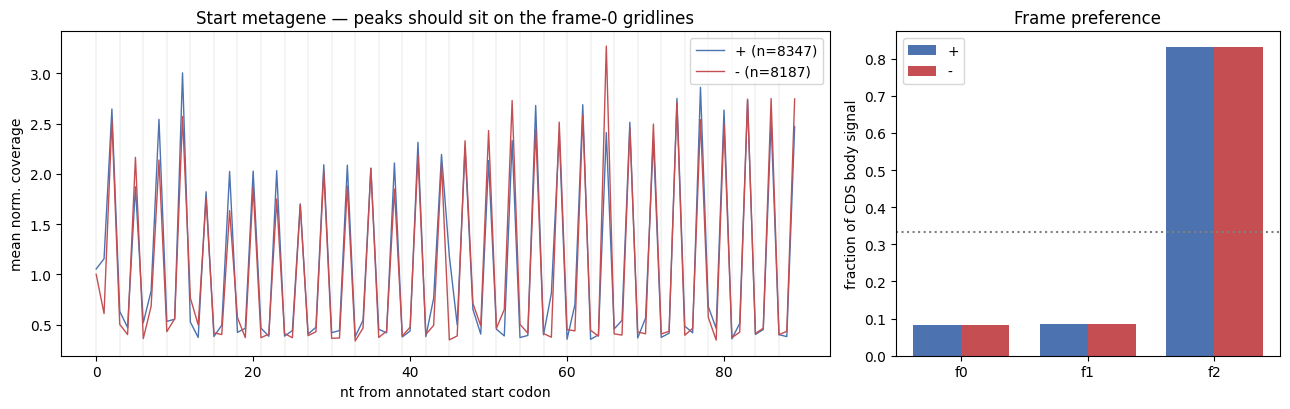

In [48]:
import re
import numpy as np
import matplotlib.pyplot as plt
from transcode_bigwig_signal_scores import BigWigPair

GTF    = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/'
              'full_pilot_results/gencode.v47.annotation.gtf')
sample = 'Ribo_Pancreas_pooled'
WIN    = 90            # nt into the CDS from the start codon, for the metagene

# 1. MANE_Select CDS intervals + start-codon anchor (known frame, one isoform/gene)
tid_re = re.compile(r'transcript_id "([^"]+)"')
tx = {}
with open(GTF) as fh:
    for line in fh:
        if line[0] == '#':
            continue
        f = line.rstrip('\n').split('\t')
        if f[2] not in ('CDS', 'start_codon') or 'MANE_Select' not in f[8]:
            continue
        tid = tid_re.search(f[8]).group(1)
        d = tx.setdefault(tid, dict(chrom=f[0], strand=f[6], cds=[], sc=None))
        s, e = int(f[3]) - 1, int(f[4])           # GTF 1-based incl -> 0-based half-open
        (d['cds'].append((s, e)) if f[2] == 'CDS' else d.__setitem__('sc', (s, e)))
tx = {t: d for t, d in tx.items() if d['cds'] and d['sc']}
print(f'{len(tx):,} MANE transcripts with CDS + start codon')

# 2. extract, accumulate start metagene + whole-CDS frame breakdown, split by strand
bws = BigWigPair(str(BIGWIG_ROOT / f'{sample}.forward.bw'),
                 str(BIGWIG_ROOT / f'{sample}.reverse.bw'))
print('bigwig chroms sample:', list(bws.handles['+'].chroms())[:3])   # sanity vs GTF 'chr...'

meta   = {'+': np.zeros(WIN), '-': np.zeros(WIN)}
nmeta  = {'+': 0, '-': 0}
frames = {'+': np.zeros(3),  '-': np.zeros(3)}
n_ok = 0
for d in tx.values():
    arr = bws.transcript_values(d['chrom'], sorted(d['cds']), d['strand'])  # idx0 = start codon
    if arr is None or len(arr) < WIN + 30 or arr.sum() <= 0:
        continue
    n_ok += 1
    body = arr[15:len(arr) - 15]                       # skip start ramp / stop peak
    pos  = np.arange(len(body)) % 3
    frames[d['strand']] += [body[pos == k].sum() for k in range(3)]
    head = arr[:WIN].astype(float)
    meta[d['strand']] += head / arr.mean()             # normalise per transcript
    nmeta[d['strand']] += 1
bws.close()
print(f'{n_ok:,} transcripts with signal')

# 3. plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={'width_ratios': [2, 1]})
for st, c in [('+', '#4C72B0'), ('-', '#C44E52')]:
    if nmeta[st]:
        m = meta[st] / nmeta[st]
        ax1.plot(range(WIN), m, color=c, lw=1, label=f'{st} (n={nmeta[st]})')
for x in range(0, WIN, 3):                              # frame-0 gridlines
    ax1.axvline(x, color='grey', lw=.3, alpha=.4)
ax1.set_xlabel('nt from annotated start codon'); ax1.set_ylabel('mean norm. coverage')
ax1.set_title('Start metagene — peaks should sit on the frame-0 gridlines'); ax1.legend()

w = .38
for off, st, c in [(-w/2, '+', '#4C72B0'), (w/2, '-', '#C44E52')]:
    fr = frames[st] / frames[st].sum() if frames[st].sum() else frames[st]
    ax2.bar(np.arange(3) + off, fr, w, color=c, label=st)
ax2.axhline(1/3, ls=':', c='grey'); ax2.set_xticks(range(3)); ax2.set_xticklabels(['f0', 'f1', 'f2'])
ax2.set_ylabel('fraction of CDS body signal'); ax2.set_title('Frame preference'); ax2.legend()
fig.tight_layout(); fig.savefig(OUT_DIR / 'gencode_periodicity_qc.png', dpi=150, bbox_inches='tight')

for st in '+-':
    if frames[st].sum():
        print(f'{st} strand dominant frame = f{frames[st].argmax()}  ({frames[st]/frames[st].sum()})')

In [49]:

# --- Per-bigWig P-site offset calibration from GENCODE MANE_Select CDS ---
# Produces the frozen per-sample scalar used by transcode_bigwig_signal_scores.py.
from calibrate_psite_offsets import calibrate_sample, load_mane_cds

bw_manifest_for_calibration = discover_bigwigs(BIGWIG_ROOT)
bw_manifest_for_calibration = bw_manifest_for_calibration[bw_manifest_for_calibration['has_pair']].copy()
bw_manifest_for_calibration = bw_manifest_for_calibration[
    bw_manifest_for_calibration['sample_id'].astype(str).isin(PANCREAS_SAMPLES)
]

if not GTF.exists():
    print(f'Skipping P-site calibration: GTF not found: {GTF}')
elif bw_manifest_for_calibration.empty:
    print(f'Skipping P-site calibration: no paired BigWigs under {BIGWIG_ROOT}')
elif not all(Path(p).exists() for p in bw_manifest_for_calibration['fwd_path']) or not all(Path(p).exists() for p in bw_manifest_for_calibration['rev_path']):
    print('Skipping P-site calibration: one or more BigWig symlink targets are unavailable.')
    display(bw_manifest_for_calibration)
else:
    transcripts = load_mane_cds(GTF)
    print(f'{len(transcripts):,} MANE_Select transcripts with CDS + start codon')
    results = {}
    rows = []
    for row in bw_manifest_for_calibration.sort_values('sample_id').itertuples(index=False):
        result = calibrate_sample(str(row.sample_id), str(row.fwd_path), str(row.rev_path), transcripts)
        results[str(row.sample_id)] = result
        rows.append({'sample_id': row.sample_id, **result})
    PSITE_OFFSETS.write_text(json.dumps(results, indent=2) + '\n')
    cal = pd.DataFrame(rows)
    display(cal)
    print(f'Wrote {PSITE_OFFSETS}')


19,225 MANE_Select transcripts with CDS + start codon


,sample_id,offset,dom_frac,dom_frac_plus,dom_frac_minus,dom_frame_plus,dom_frame_minus,n_tx
0,Ribo_Pancreas_pooled,1,0.832,0.832,0.832,2,2,16526
1,SRR11005875_to_79,1,0.849,0.850,0.849,2,2,14951
2,SRR11005880_to_84,1,0.832,0.833,0.832,2,2,15432
3,SRR11005885_to_89,1,0.839,0.839,0.839,2,2,15410
4,SRR11005890_to_94,1,0.833,0.833,0.833,2,2,15310
5,SRR11005895_to_99,1,0.814,0.814,0.814,2,2,15397
6,SRR11005900_to_04,1,0.829,0.829,0.830,2,2,15416


Wrote figures_bigwig_pancreas_fallback/psite_offsets.json


In [50]:
# Calibration is handled by the previous cell via calibrate_psite_offsets.py helpers.


In [51]:
def frame_fractions(arr, start_offset=0):
    """All three frame fractions, annotated frame first (frame 0)."""
    if arr is None or len(arr) < 9:
        return (np.nan, np.nan, np.nan)
    positions = (np.arange(len(arr)) + start_offset) % 3
    fs = np.array([arr[positions == k].sum() for k in range(3)], dtype=float)
    tot = fs.sum()
    return tuple(fs / tot) if tot > 0 else (np.nan, np.nan, np.nan)

## Quick checks

The scoring functions are deterministic and cheap to test before touching BigWigs.


In [52]:
test_arr = np.array([10, 0, 0, 8, 0, 0, 6, 0, 0, 4, 0, 0], dtype=float)
flat_arr = np.ones(12, dtype=float)
assert abs(periodicity_score(test_arr) - 1.0) < 1e-6
assert abs(periodicity_score(flat_arr) - 1/3) < 1e-6
assert 0 < uniformity_score(test_arr) <= 1
assert abs(uniformity_score(flat_arr) - 1.0) < 1e-6

frame2_arr = np.zeros(30, dtype=float)
frame2_arr[np.arange(len(frame2_arr)) % 3 == 2] = 1.0
assert abs(periodicity_score(frame2_arr, start_offset=1) - 1.0) < 1e-6
assert abs(periodicity_score(frame2_arr, start_offset=0) - 0.0) < 1e-6
print('Metric self-tests passed.')


Metric self-tests passed.


## Pancreas BigWig discovery

The grouped pancreas BigWigs are named `<sample>.<mode>.<strand>.bw`. The setup cell links the selected mode to the scorer-compatible names `<sample>.<strand>.bw`.


In [53]:
expected = pd.MultiIndex.from_product([PANCREAS_SAMPLES, ['forward', 'reverse']], names=['sample_id', 'strand']).to_frame(index=False)
expected['source_path'] = expected.apply(lambda r: GROUPED_BIGWIG_ROOT / f"{r.sample_id}.{SIGNAL_MODE}.{r.strand}.bw", axis=1)
expected['exists'] = expected['source_path'].map(lambda p: Path(p).exists())
display(expected)
missing = expected[~expected['exists']]
if not missing.empty:
    print('Missing selected-mode pancreas BigWigs:')
    display(missing)

bw_manifest = discover_bigwigs(BIGWIG_ROOT)
print(f'BigWig samples found for selected mode: {len(bw_manifest):,}')
if not bw_manifest.empty:
    print(f'Paired stranded BigWigs: {int(bw_manifest.has_pair.sum()):,}')
    display(bw_manifest)
else:
    print('No scorer-compatible BigWigs found yet.')


,sample_id,strand,source_path,exists
0,SRR11005875_to_79,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
1,SRR11005875_to_79,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
2,SRR11005880_to_84,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
3,SRR11005880_to_84,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
4,SRR11005885_to_89,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
5,SRR11005885_to_89,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
6,SRR11005890_to_94,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
7,SRR11005890_to_94,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
8,SRR11005895_to_99,forward,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True
9,SRR11005895_to_99,reverse,/hps/nobackup/flicek/ensembl/genebuild/jackt/r...,True


BigWig samples found for selected mode: 7
Paired stranded BigWigs: 7


,sample_id,fwd_path,rev_path,has_pair
0,Ribo_Pancreas_pooled,figures_bigwig_pancreas_fallback/bigwig_links_...,figures_bigwig_pancreas_fallback/bigwig_links_...,True
1,SRR11005875_to_79,figures_bigwig_pancreas_fallback/bigwig_links_...,figures_bigwig_pancreas_fallback/bigwig_links_...,True
2,SRR11005880_to_84,figures_bigwig_pancreas_fallback/bigwig_links_...,figures_bigwig_pancreas_fallback/bigwig_links_...,True
3,SRR11005885_to_89,figures_bigwig_pancreas_fallback/bigwig_links_...,figures_bigwig_pancreas_fallback/bigwig_links_...,True
4,SRR11005890_to_94,figures_bigwig_pancreas_fallback/bigwig_links_...,figures_bigwig_pancreas_fallback/bigwig_links_...,True
5,SRR11005895_to_99,figures_bigwig_pancreas_fallback/bigwig_links_...,figures_bigwig_pancreas_fallback/bigwig_links_...,True
6,SRR11005900_to_04,figures_bigwig_pancreas_fallback/bigwig_links_...,figures_bigwig_pancreas_fallback/bigwig_links_...,True


## Score pancreas translon features

This scores only samples with paired BigWigs in the selected pancreas signal mode. The default is bounded to 2,000 unique feature/sample signals per sample for fast presentation fallback output.


In [54]:

cfg = ScoreConfig(
    flank_nt=30,
    body_edge_nt=15,
    min_body_nt=30,
    min_total_signal=10.0,
    max_features_per_sample=2000,   # set None for full production scoring
    max_total_features=None,        # optional hard global cap for smoke tests
    overwrite=False,                # existing per-sample checkpoints are reused when offsets match
)

existing_scores = OUT_DIR / 'translon_signal_scores.tsv.gz'
summary_path = OUT_DIR / 'signal_score_summary.json'
psite_offsets = load_psite_offsets(PSITE_OFFSETS)

def summary_has_matching_offsets(summary, offsets):
    samples = summary.get('samples', []) if isinstance(summary, dict) else []
    if not offsets or not samples:
        return False
    for sample in samples:
        sid = str(sample.get('sample_id'))
        if 'psite_offset' not in sample:
            return False
        if int(sample['psite_offset']) != int(offsets.get(sid, 0)):
            return False
    return True

if HAS_PYBIGWIG and DB.exists() and BIGWIG_ROOT.exists() and psite_offsets and SCORER_SUPPORTS_PSITE:
    scored_unique, run_summary = score_database(DB, BIGWIG_ROOT, OUT_DIR, cfg, psite_offsets=psite_offsets)
else:
    print('Skipping extraction because pyBigWig, DB, BigWig root, or P-site offsets are unavailable.')
    if existing_scores.exists():
        print(f'Loading existing scores: {existing_scores}')
        scored_unique = pd.read_csv(existing_scores, sep='\t')
        run_summary = json.loads(summary_path.read_text()) if summary_path.exists() else {'result_rows': len(scored_unique), 'loaded_existing': True}
    else:
        scored_unique = pd.DataFrame()
        run_summary = {'result_rows': 0, 'loaded_existing': False}

SCORES_ARE_REGISTERED = summary_has_matching_offsets(run_summary, psite_offsets)
if not SCORES_ARE_REGISTERED:
    print('WARNING: loaded scores are not P-site registered; periodicity/evidence plots will be skipped.')

scored = expand_scores_by_tool(scored_unique)
print(f'Unique feature/sample score rows: {len(scored_unique):,}')
print(f'Tool-expanded rows for plots: {len(scored):,}')
if not scored_unique.empty:
    display(scored_unique.head())

print('\nCalibration CLI for selected mode:')
print(
    'python3 calibrate_psite_offsets.py '
    f'--gtf {GTF} --bigwig-root {BIGWIG_ROOT} --samples ' + ' '.join(PANCREAS_SAMPLES) + f' --out {PSITE_OFFSETS}'
)
print('\nFull-scale pancreas fallback CLI for selected mode, resumable from existing sample checkpoints:')
print(
    'python3 transcode_bigwig_signal_scores.py '
    f'--db {DB} --bigwig-root {BIGWIG_ROOT} --out-dir {OUT_DIR} '
    f'--psite-offsets {PSITE_OFFSETS} --full --overwrite'
)


Skipping extraction because pyBigWig, DB, BigWig root, or P-site offsets are unavailable.
Loading existing scores: figures_bigwig_pancreas_fallback/translon_signal_scores.tsv.gz
Unique feature/sample score rows: 8,648
Tool-expanded rows for plots: 13,602


,feature_key,sample_id,bed_chrom,bed_start,bed_end,bed_strand,spliced_length_nt,extract_status,orf_signal_nt,mean_cov,...,start_window_total_signal,start_upstream_total_signal,stop_pre_total_signal,stop_post_total_signal,upstream_flank_nt,downstream_flank_nt,flank_note,source_tools,classes,tool_rows
0,"chr10:100042426-100081625:-:147,119,100,140,11...",Ribo_Pancreas_pooled,chr10,100042426,100081625,-,1377,ok,1377,2.638,...,29.000,36.000,33.000,0.000,30,30,genomic_flanks_not_splice_aware,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds,5
1,chr10:100081539-100081737:-:198:0,Ribo_Pancreas_pooled,chr10,100081539,100081737,-,198,ok,198,1.045,...,5.000,6.000,42.000,259.000,30,30,genomic_flanks_not_splice_aware,PRICE,cds,1
2,chr10:100081788-100081815:-:27:0,Ribo_Pancreas_pooled,chr10,100081788,100081815,-,27,ok,27,5.593,...,151.000,31.000,151.000,8.000,30,30,genomic_flanks_not_splice_aware,ORFQuant|PRICE|RibORF2|iRibo,cds|non_cds,4
3,"chr10:100152130-100185626:-:222,80,90,92,59,74...",Ribo_Pancreas_pooled,chr10,100152130,100185626,-,1047,ok,1047,11.543,...,338.000,38.000,404.000,5.000,30,30,genomic_flanks_not_splice_aware,ORFQuant|PRICE|RibORF2|RiboTIE|iRibo,cds,5
4,chr10:100185660-100185771:-:111:0,Ribo_Pancreas_pooled,chr10,100185660,100185771,-,111,ok,111,1.982,...,24.000,9.000,64.000,0.000,30,30,genomic_flanks_not_splice_aware,PRICE|RibORF2|RiboTIE|iRibo,cds|non_cds,4



Calibration CLI for selected mode:
python3 calibrate_psite_offsets.py --gtf /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/gencode.v47.annotation.gtf --bigwig-root figures_bigwig_pancreas_fallback/bigwig_links_unique_no_junction --samples SRR11005875_to_79 SRR11005880_to_84 SRR11005885_to_89 SRR11005890_to_94 SRR11005895_to_99 SRR11005900_to_04 Ribo_Pancreas_pooled --out figures_bigwig_pancreas_fallback/psite_offsets.json

Full-scale pancreas fallback CLI for selected mode, resumable from existing sample checkpoints:
python3 transcode_bigwig_signal_scores.py --db /hps/nobackup/flicek/ensembl/genebuild/jackt/riboseq/pilot/full_pilot_results/translon_db_rebuild/translon_db/translons.sqlite --bigwig-root figures_bigwig_pancreas_fallback/bigwig_links_unique_no_junction --out-dir figures_bigwig_pancreas_fallback --psite-offsets figures_bigwig_pancreas_fallback/psite_offsets.json --full --overwrite


## Scope Note

All plots below are pancreas-only and use the selected signal mode. They should be labelled as Ribo-seq profile integration for the pancreas subset, not the full pilot.


## Pancreas QC summaries

`coverage_pass` is based on body signal only. Start and stop flank metrics are marked as genomic-flank based because the translon DB currently stores ORF blocks, not full transcript exon models for splice-aware UTR flanks.


In [55]:
if scored_unique.empty:
    print('No scored features available.')
else:
    summary_cols = [
        'mean_cov', 'body_mean_cov', 'periodicity', 'uniformity',
        'start_rise_ratio', 'stop_dropoff_ratio', 'body_total_signal',
        'upstream_flank_nt', 'downstream_flank_nt'
    ]
    present = [c for c in summary_cols if c in scored_unique]
    display(scored_unique[present].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
    print('\nCoverage pass counts:')
    display(scored_unique['coverage_pass'].value_counts(dropna=False).rename('features'))



/homes/jackt/.local/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a
/homes/jackt/.local/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/homes/jackt/.local/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,mean_cov,body_mean_cov,periodicity,uniformity,start_rise_ratio,stop_dropoff_ratio,body_total_signal,upstream_flank_nt,downstream_flank_nt
count,8648.000,8648.000,8191.000,8191.000,7534.000,6458.000,8648.000,8648.000,8648.000
mean,1.747,1.785,0.111,0.348,inf,inf,1118.823,30.000,30.000
std,6.355,6.626,0.116,0.086,NaN,NaN,4083.918,0.000,0.000
min,0.000,0.000,0.000,0.037,0.000,0.000,0.000,30.000,30.000
10%,0.036,0.031,0.000,0.235,0.242,0.000,5.000,30.000,30.000
25%,0.178,0.167,0.062,0.304,0.750,0.000,21.000,30.000,30.000
50%,0.495,0.491,0.087,0.358,2.267,0.000,138.000,30.000,30.000
75%,1.316,1.322,0.121,0.399,11.500,0.364,722.500,30.000,30.000
90%,3.241,3.235,0.200,0.442,NaN,2.518,2694.300,30.000,30.000
max,189.924,194.899,1.000,0.870,inf,inf,204644.000,30.000,30.000



Coverage pass counts:


coverage_pass
True     7356
False    1292
Name: features, dtype: int64

## Pancreas signal metric distributions


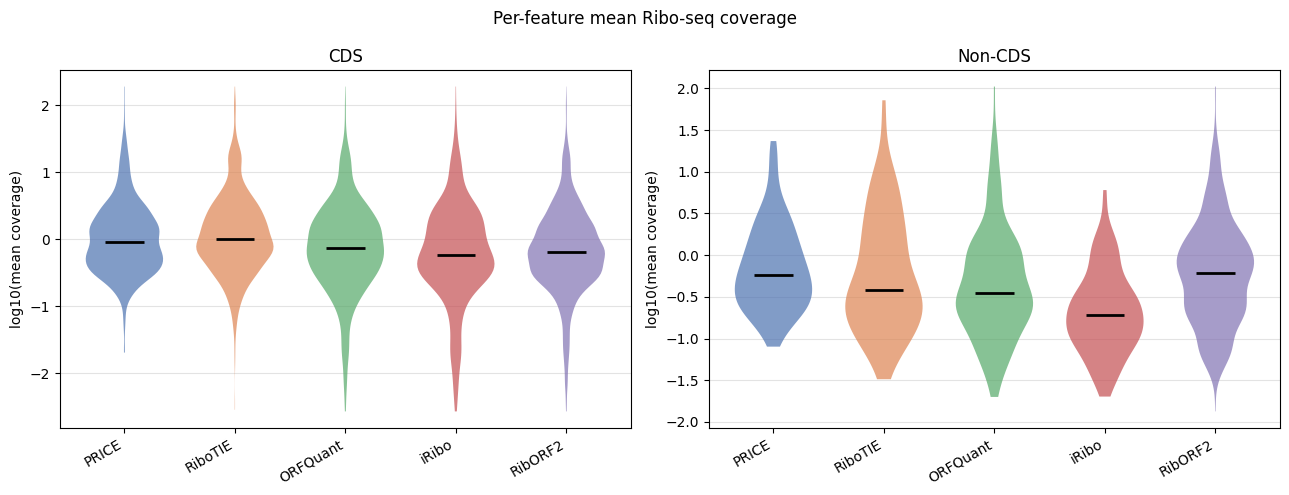

Saved figures_bigwig_pancreas_fallback/mean_cov_distribution.png
Skipping periodicity_distribution.png: scores are not P-site registered.


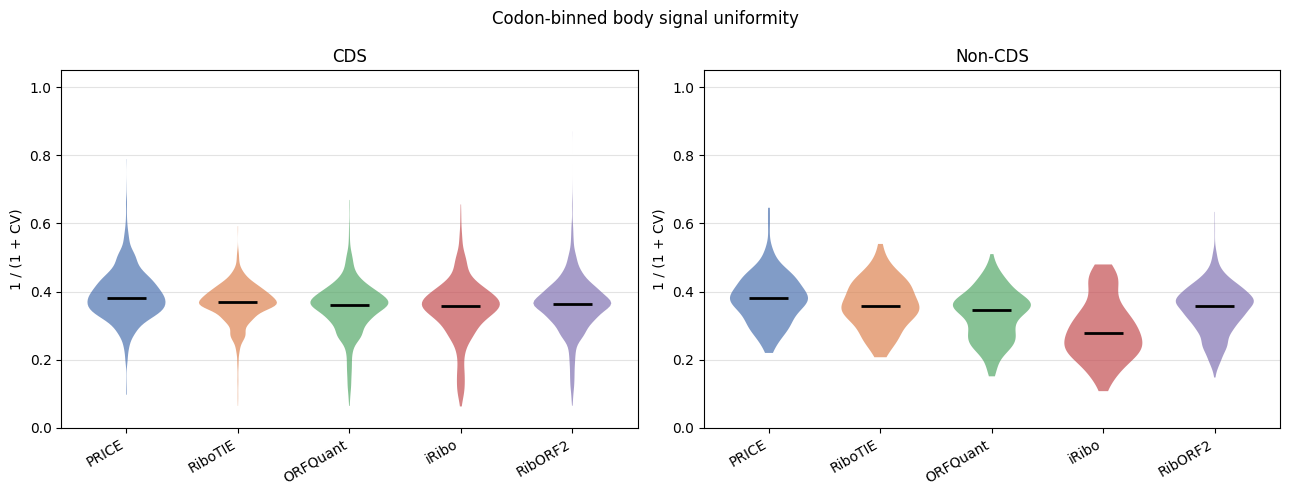

Saved figures_bigwig_pancreas_fallback/uniformity_distribution.png


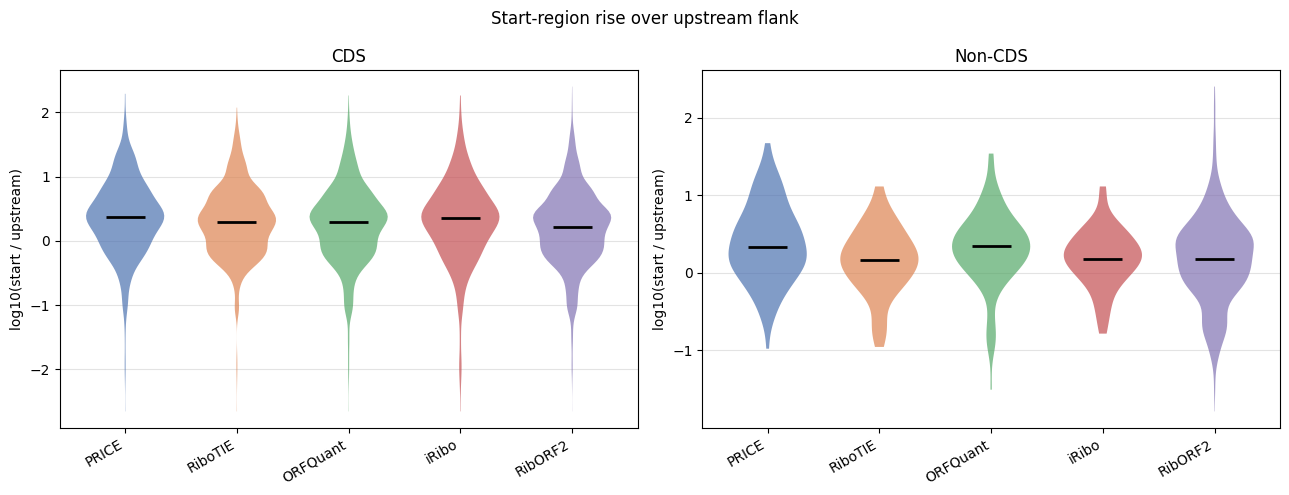

Saved figures_bigwig_pancreas_fallback/start_rise_ratio_distribution.png


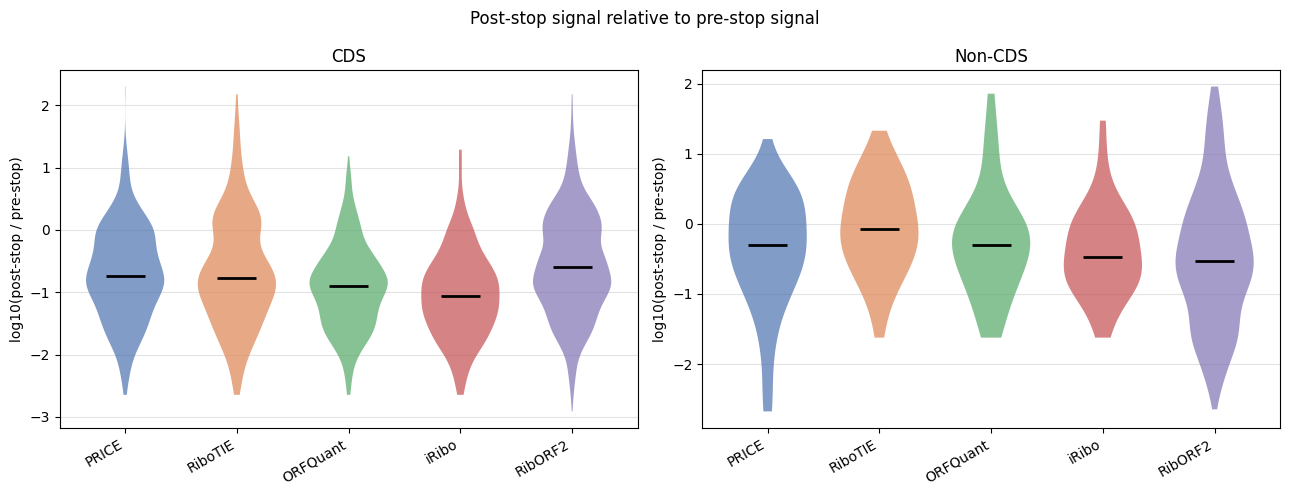

Saved figures_bigwig_pancreas_fallback/stop_dropoff_ratio_distribution.png


In [56]:
def tools_present(df):
    return [t for t in TOOL_ORDER if 'source_tool' in df and t in set(df['source_tool'].dropna())]


def plot_metric_by_tool(df, metric, title, ylabel, log=False, finite_positive=False, ylim=None):
    if df.empty or metric not in df:
        print(f'Skipping {metric}: no data.')
        return
    tools = tools_present(df)
    if not tools:
        print(f'Skipping {metric}: no source_tool data.')
        return

    fig, axes = plt.subplots(1, len(CLS_ORDER), figsize=(13, 5), squeeze=False)
    for ax, cls in zip(axes[0], CLS_ORDER):
        sub = df[df['cls'] == cls] if 'cls' in df else df
        positions = list(range(1, len(tools) + 1))
        for pos, tool in zip(positions, tools):
            vals = pd.to_numeric(sub[sub['source_tool'] == tool][metric], errors='coerce').to_numpy(dtype=float)
            vals = vals[np.isfinite(vals)]
            if finite_positive:
                vals = vals[vals > 0]
            if len(vals) < 5:
                continue
            if log:
                vals = np.log10(vals)
            parts = ax.violinplot([vals], positions=[pos], widths=0.7, showmedians=True, showextrema=False)
            for pc in parts['bodies']:
                pc.set_facecolor(TOOL_COLORS.get(tool, '#888'))
                pc.set_alpha(0.7)
            parts['cmedians'].set_color('black')
            parts['cmedians'].set_linewidth(2)
        ax.set_xticks(positions)
        ax.set_xticklabels(tools, rotation=30, ha='right')
        ax.set_title(f'{CLS_LABELS.get(cls, cls)}')
        ax.set_ylabel(ylabel)
        if ylim:
            ax.set_ylim(*ylim)
        ax.yaxis.grid(True, alpha=0.35)
        ax.set_axisbelow(True)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    out = OUT_DIR / f'{metric}_distribution.png'
    fig.savefig(out, dpi=180)
    plt.show()
    print(f'Saved {out}')

if scored.empty:
    print('No scored ORFs available for plots.')
else:
    plot_df = scored[scored.get('coverage_pass', True).astype(bool)].copy() if 'coverage_pass' in scored else scored.copy()
    plot_metric_by_tool(plot_df, 'mean_cov', 'Per-feature mean Ribo-seq coverage', 'log10(mean coverage)', log=True, finite_positive=True)
    if SCORES_ARE_REGISTERED:
        plot_metric_by_tool(plot_df, 'periodicity', '3-nt periodicity over ORF body', 'registered annotated-frame signal fraction', ylim=(0, 1.05))
    else:
        print('Skipping periodicity_distribution.png: scores are not P-site registered.')
    plot_metric_by_tool(plot_df, 'uniformity', 'Codon-binned body signal uniformity', '1 / (1 + CV)', ylim=(0, 1.05))
    plot_metric_by_tool(plot_df, 'start_rise_ratio', 'Start-region rise over upstream flank', 'log10(start / upstream)', log=True, finite_positive=True)
    plot_metric_by_tool(plot_df, 'stop_dropoff_ratio', 'Post-stop signal relative to pre-stop signal', 'log10(post-stop / pre-stop)', log=True, finite_positive=True)


## Pancreas shared-feature cross-tool comparison


In [57]:
if scored.empty or 'source_tool' not in scored:
    print('No scored ORFs available for cross-tool comparison.')
elif not SCORES_ARE_REGISTERED:
    print('Skipping cross-tool periodicity comparison: scores are not P-site registered.')
else:
    shared_fks = (
        scored.groupby(['feature_key', 'sample_id'])['source_tool']
              .nunique()
              .pipe(lambda s: s[s >= 2])
              .index
    )
    scored_shared = scored[
        scored.set_index(['feature_key', 'sample_id']).index.isin(shared_fks)
    ].copy()
    print(f'Shared feature/sample rows: {len(scored_shared):,}')

    metric = 'periodicity'
    tool_pairs = [(TOOL_ORDER[i], TOOL_ORDER[j]) for i in range(len(TOOL_ORDER)) for j in range(i + 1, len(TOOL_ORDER))]
    valid_pairs = [(a, b) for a, b in tool_pairs if a in set(scored_shared['source_tool']) and b in set(scored_shared['source_tool'])]

    if len(scored_shared) < 10 or not valid_pairs:
        print('Too few shared ORFs for cross-tool scatter.')
    else:
        ncols = min(3, len(valid_pairs))
        nrows = (len(valid_pairs) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
        for idx, (t1, t2) in enumerate(valid_pairs):
            ax = axes[idx // ncols][idx % ncols]
            sub1 = scored_shared[scored_shared['source_tool'] == t1][['feature_key', 'sample_id', metric]].rename(columns={metric: 'm1'})
            sub2 = scored_shared[scored_shared['source_tool'] == t2][['feature_key', 'sample_id', metric]].rename(columns={metric: 'm2'})
            merged = sub1.merge(sub2, on=['feature_key', 'sample_id']).dropna()
            if len(merged) < 3:
                ax.set_visible(False)
                continue
            ax.scatter(merged['m1'], merged['m2'], alpha=0.35, s=10, color='#555')
            ax.plot([0, 1], [0, 1], 'r--', lw=1)
            ax.axhline(1/3, color='grey', lw=0.7, linestyle=':')
            ax.axvline(1/3, color='grey', lw=0.7, linestyle=':')
            corr = merged['m1'].corr(merged['m2'])
            ax.set_xlabel(f'{t1} {metric}')
            ax.set_ylabel(f'{t2} {metric}')
            ax.set_title(f'{t1} vs {t2}\n(r={corr:.2f}, n={len(merged):,})')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
        for idx in range(len(valid_pairs), nrows * ncols):
            axes[idx // ncols][idx % ncols].set_visible(False)
        fig.suptitle('Cross-tool periodicity comparison for shared feature_keys', fontsize=12)
        plt.tight_layout()
        out = OUT_DIR / 'cross_tool_periodicity_scatter.png'
        fig.savefig(out, dpi=180)
        plt.show()
        print(f'Saved {out}')


Skipping cross-tool periodicity comparison: scores are not P-site registered.


## Pancreas CDS recall versus signal


Scored CDS rows: recalled=5,579, not-recalled=4,520


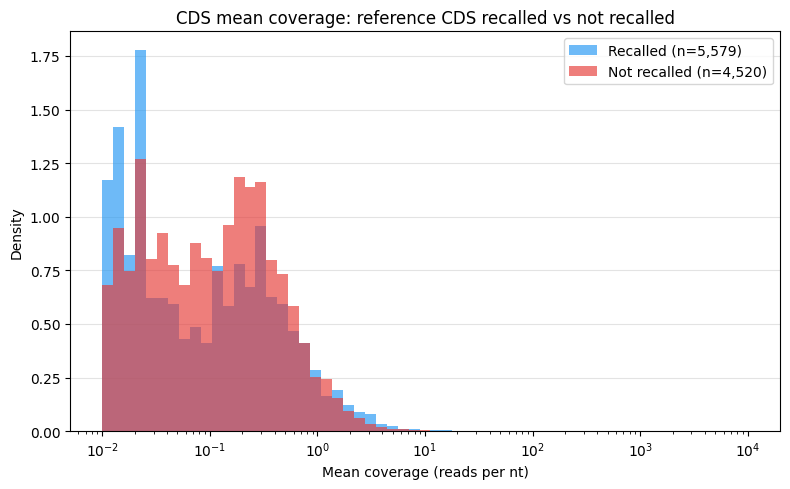

Saved figures_bigwig_pancreas_fallback/cds_recall_vs_coverage.png
Median coverage: recalled=0.848; not-recalled=0.550


In [58]:
if scored.empty or not DB.exists():
    print('No scored ORFs or DB unavailable; skipping CDS recall plot.')
else:
    con = sqlite3.connect(DB)
    ref = pd.read_sql_query('SELECT feature_key, stop_excluded_feature_key FROM reference_cds', con)
    con.close()
    ref_fks = set(ref['feature_key'].dropna()) | set(ref['stop_excluded_feature_key'].dropna())

    scored_cds = scored[scored['cls'] == 'cds'].copy()
    scored_cds['recalled'] = scored_cds['feature_key'].isin(ref_fks)
    recalled_cov = scored_cds[scored_cds['recalled'] & (scored_cds['mean_cov'] > 0)]['mean_cov'].dropna()
    not_recalled_cov = scored_cds[~scored_cds['recalled'] & (scored_cds['mean_cov'] > 0)]['mean_cov'].dropna()
    print(f'Scored CDS rows: recalled={len(recalled_cov):,}, not-recalled={len(not_recalled_cov):,}')

    if len(recalled_cov) and len(not_recalled_cov):
        fig, ax = plt.subplots(figsize=(8, 5))
        bins = np.logspace(-2, 4, 60)
        ax.hist(recalled_cov, bins=bins, color='#2196F3', alpha=0.65, label=f'Recalled (n={len(recalled_cov):,})', density=True)
        ax.hist(not_recalled_cov, bins=bins, color='#E53935', alpha=0.65, label=f'Not recalled (n={len(not_recalled_cov):,})', density=True)
        ax.set_xscale('log')
        ax.set_xlabel('Mean coverage (reads per nt)')
        ax.set_ylabel('Density')
        ax.set_title('CDS mean coverage: reference CDS recalled vs not recalled')
        ax.legend()
        ax.yaxis.grid(True, alpha=0.35)
        ax.set_axisbelow(True)
        plt.tight_layout()
        out = OUT_DIR / 'cds_recall_vs_coverage.png'
        fig.savefig(out, dpi=180)
        plt.show()
        print(f'Saved {out}')
        print(f'Median coverage: recalled={np.median(recalled_cov):.3f}; not-recalled={np.median(not_recalled_cov):.3f}')


In [59]:

POOLED = {'Ribo_Pancreas_pooled'}
EV     = 'periodicity'      # registered annotated-frame signal fraction
NULL   = 1 / 3

if scored_unique.empty:
    print('No scored rows available for evidence plots.')
    su = pd.DataFrame()
    cp = pd.DataFrame()
elif not SCORES_ARE_REGISTERED:
    print('Skipping evidence plots: scores are not P-site registered. Regenerate with psite_offsets.json first.')
    su = scored_unique.copy()
    cp = pd.DataFrame()
else:
    su = scored_unique.copy()
    su['tools']   = su['source_tools'].str.split('|')
    su['n_tools'] = su['tools'].str.len()
    su['is_cds']  = su['classes'].fillna('').apply(lambda s: 'cds' in s.split('|'))

    assert not su.duplicated(['feature_key', 'sample_id']).any(), 'frame is not unique per (feature, sample)'

    cp = su[su['coverage_pass']].copy()
    EV_HI = cp.loc[cp['is_cds'], EV].median()
    print(f'{len(su):,} rows, {len(cp):,} pass coverage; CDS-median {EV} = {EV_HI:.2f}')
    print('tier sizes:', cp['n_tools'].value_counts().sort_index().to_dict())
    if (su.groupby('sample_id').size() >= 2000).any():
        print('some samples are at the 2000 cap - re-run with max_features_per_sample=None before trusting this')


Skipping evidence plots: scores are not P-site registered. Regenerate with psite_offsets.json first.


In [60]:
if not SCORES_ARE_REGISTERED or cp.empty:
    print('Skipping: registered evidence scores are unavailable.')
else:
    # the one plot we deliberately expand by tool
    bt = su.explode('tools').rename(columns={'tools': 'tool'})
    bt = bt[bt.tool.isin(TOOL_ORDER)]

    frac = bt.groupby('tool')['coverage_pass'].mean().reindex(TOOL_ORDER).dropna()
    n    = bt.groupby('tool').size()[frac.index]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={'width_ratios': [1, 1.3]})

    ax1.bar(frac.index, frac.values, color=[TOOL_COLORS[t] for t in frac.index])
    for i, t in enumerate(frac.index):
        ax1.text(i, frac[t] + .01, f'{frac[t]:.0%}\nn={n[t]:,}', ha='center', va='bottom', fontsize=8)
    ax1.set_ylim(0, 1); ax1.set_ylabel('calls reaching coverage_pass')
    ax1.set_title("How much of each tool's output is data-backed?")
    ax1.text(0, -.16, 'low bar = ORFs called with no coverage = prior-driven, not data-driven',
             transform=ax1.transAxes, fontsize=8, color='#555')

    passed = bt[bt.coverage_pass]
    here   = [t for t in TOOL_ORDER if t in set(passed.tool)]
    parts  = ax2.violinplot([passed.loc[passed.tool == t, EV].dropna() for t in here], showmedians=True)
    for body, t in zip(parts['bodies'], here):
        body.set_facecolor(TOOL_COLORS[t]); body.set_alpha(.6)
    ax2.axhline(EV_HI, ls='--', c='k', lw=1); ax2.axhline(NULL, ls=':', c='grey', lw=1)
    ax2.set_xticks(range(1, len(here) + 1)); ax2.set_xticklabels(here); ax2.set_ylabel(EV)
    ax2.set_title('...and how good is the evidence where it passes?')
    fig.tight_layout(); fig.savefig(OUT_DIR / '17_coverage_and_evidence_by_tool.png', dpi=150, bbox_inches='tight')


Skipping: registered evidence scores are unavailable.


In [61]:
if not SCORES_ARE_REGISTERED or cp.empty:
    print('Skipping: registered evidence scores are unavailable.')
else:
    tiers = sorted(cp['n_tools'].unique())
    data  = [cp.loc[cp.n_tools == k, EV].dropna() for k in tiers]

    fig, ax = plt.subplots(figsize=(8, 4.6))
    parts = ax.violinplot(data, positions=tiers, showmedians=True, widths=.8)
    for body in parts['bodies']:
        body.set_facecolor('#4878a8'); body.set_alpha(.55)

    meds = [d.median() for d in data]
    ax.plot(tiers, meds, 'o-', c='k', lw=1, ms=4)
    for k, m, d in zip(tiers, meds, data):
        ax.text(k, m + .02, f'{m:.2f}\nn={len(d):,}', ha='center', va='bottom', fontsize=8)

    ax.axhline(EV_HI, ls='--', c='k', lw=1); ax.axhline(NULL, ls=':', c='grey', lw=1)
    ax.set_xticks(tiers); ax.set_xlabel('# tools calling this ORF (same sample)'); ax.set_ylabel(EV)
    ax.set_title('Does agreement track evidence?')
    ax.text(0, -.16, 'if consensus meant truth, the medians would climb left → right',
            transform=ax.transAxes, fontsize=8, color='#555')
    fig.tight_layout(); fig.savefig(OUT_DIR / '12_evidence_vs_consensus_tier.png', dpi=150, bbox_inches='tight')


Skipping: registered evidence scores are unavailable.


In [62]:
if not SCORES_ARE_REGISTERED or cp.empty:
    print('Skipping: registered evidence scores are unavailable.')
else:
    tiers = sorted(cp['n_tools'].unique())
    data  = [cp.loc[cp.n_tools == k, EV].dropna() for k in tiers]

    fig, ax = plt.subplots(figsize=(8, 4.6))
    parts = ax.violinplot(data, positions=tiers, showmedians=True, widths=.8)
    for body in parts['bodies']:
        body.set_facecolor('#4878a8'); body.set_alpha(.55)

    meds = [d.median() for d in data]
    ax.plot(tiers, meds, 'o-', c='k', lw=1, ms=4)
    for k, m, d in zip(tiers, meds, data):
        ax.text(k, m + .02, f'{m:.2f}\nn={len(d):,}', ha='center', va='bottom', fontsize=8)

    ax.axhline(EV_HI, ls='--', c='k', lw=1); ax.axhline(NULL, ls=':', c='grey', lw=1)
    ax.set_xticks(tiers); ax.set_xlabel('# tools calling this ORF (same sample)'); ax.set_ylabel(EV)
    ax.set_title('Does agreement track evidence?')
    ax.text(0, -.16, 'if consensus meant truth, the medians would climb left → right',
            transform=ax.transAxes, fontsize=8, color='#555')
    fig.tight_layout(); fig.savefig(OUT_DIR / '12_evidence_vs_consensus_tier.png', dpi=150, bbox_inches='tight')


Skipping: registered evidence scores are unavailable.


In [63]:
if not SCORES_ARE_REGISTERED or cp.empty:
    print('Skipping: registered evidence scores are unavailable.')
else:
    q = cp.assign(consensus=np.where(cp.n_tools >= 2, 'multi-tool', 'singleton'),
                  evidence=np.where(cp[EV] >= EV_HI, 'high-evidence', 'low-evidence'))
    tab = (q.pivot_table(index='consensus', columns='evidence', values='feature_key',
                         aggfunc='count', fill_value=0)
            .reindex(['multi-tool', 'singleton'], columns=['low-evidence', 'high-evidence']))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})

    x  = cp.n_tools + np.random.uniform(-.18, .18, len(cp))   # jitter integer tiers
    hb = ax1.hexbin(x, cp[EV], gridsize=30, bins='log', cmap='viridis', mincnt=1)
    ax1.axhline(EV_HI, ls='--', c='w', lw=1.2)
    ax1.set_xlabel('consensus tier (jittered)'); ax1.set_ylabel(EV); ax1.set_title('where the calls land')
    fig.colorbar(hb, ax=ax1, label='log count')

    note  = {('multi-tool', 'low-evidence'): 'shared false positives',
             ('singleton', 'high-evidence'): 'real ORFs one tool finds alone'}
    total = tab.values.sum()
    ax2.imshow(tab.values, cmap='Blues', aspect='auto')
    for i, r in enumerate(tab.index):
        for j, c in enumerate(tab.columns):
            v = tab.values[i, j]; tag = note.get((r, c), '')
            ax2.text(j, i, f'{v:,}\n{v/total:.0%}' + (f'\n← {tag}' if tag else ''),
                     ha='center', va='center', fontsize=9,
                     color='white' if v > total * .25 else 'black')
    ax2.set_xticks(range(2)); ax2.set_xticklabels(tab.columns)
    ax2.set_yticks(range(2)); ax2.set_yticklabels(tab.index)
    ax2.set_title('off-diagonal = the science')
    fig.tight_layout(); fig.savefig(OUT_DIR / '13_consensus_x_evidence.png', dpi=150, bbox_inches='tight')


Skipping: registered evidence scores are unavailable.


In [64]:
if not SCORES_ARE_REGISTERED or cp.empty:
    print('Skipping: registered evidence scores are unavailable.')
else:
    q = cp.assign(consensus=np.where(cp.n_tools >= 2, 'multi-tool', 'singleton'),
                  evidence=np.where(cp[EV] >= EV_HI, 'high-evidence', 'low-evidence'))
    tab = (q.pivot_table(index='consensus', columns='evidence', values='feature_key',
                         aggfunc='count', fill_value=0)
            .reindex(['multi-tool', 'singleton'], columns=['low-evidence', 'high-evidence']))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})

    x  = cp.n_tools + np.random.uniform(-.18, .18, len(cp))   # jitter integer tiers
    hb = ax1.hexbin(x, cp[EV], gridsize=30, bins='log', cmap='viridis', mincnt=1)
    ax1.axhline(EV_HI, ls='--', c='w', lw=1.2)
    ax1.set_xlabel('consensus tier (jittered)'); ax1.set_ylabel(EV); ax1.set_title('where the calls land')
    fig.colorbar(hb, ax=ax1, label='log count')

    note  = {('multi-tool', 'low-evidence'): 'shared false positives',
             ('singleton', 'high-evidence'): 'real ORFs one tool finds alone'}
    total = tab.values.sum()
    ax2.imshow(tab.values, cmap='Blues', aspect='auto')
    for i, r in enumerate(tab.index):
        for j, c in enumerate(tab.columns):
            v = tab.values[i, j]; tag = note.get((r, c), '')
            ax2.text(j, i, f'{v:,}\n{v/total:.0%}' + (f'\n← {tag}' if tag else ''),
                     ha='center', va='center', fontsize=9,
                     color='white' if v > total * .25 else 'black')
    ax2.set_xticks(range(2)); ax2.set_xticklabels(tab.columns)
    ax2.set_yticks(range(2)); ax2.set_yticklabels(tab.index)
    ax2.set_title('off-diagonal = the science')
    fig.tight_layout(); fig.savefig(OUT_DIR / '13_consensus_x_evidence.png', dpi=150, bbox_inches='tight')


Skipping: registered evidence scores are unavailable.


In [65]:
if not SCORES_ARE_REGISTERED or cp.empty:
    print('Skipping: registered evidence scores are unavailable.')
else:
    # which non-CDS calls are pooled-only vs also seen in an individual pancreas sample?
    with sqlite3.connect(DB) as con:
        calls = pd.read_sql("SELECT DISTINCT source_tool, feature_key, sample_id FROM translons "
                            "WHERE qc_status='pass' AND source_feature_class='non_cds' "
                            "AND sample_id NOT GLOB '*_fastq'", con)
    calls = calls[calls.sample_id.isin(PANCREAS_SAMPLES)]

    rows = []
    for tool, g in calls.groupby('source_tool'):
        pooled = g[g.sample_id.isin(POOLED)]
        if pooled.empty:
            continue
        indiv = set(g[~g.sample_id.isin(POOLED)].feature_key)
        sid   = pooled.sample_id.iloc[0]
        for fk in set(pooled.feature_key):
            rows.append((tool, sid, fk, 'shared' if fk in indiv else 'pooled-only'))
    cls = pd.DataFrame(rows, columns=['tool', 'sample_id', 'feature_key', 'kind'])

    # evidence at the pooled sample
    m = cls.merge(cp[['feature_key', 'sample_id', EV]], on=['feature_key', 'sample_id'])
    assert not m.empty, 'join empty — were the pooled bigwigs scored, and do sample_ids match?'
    print(m.kind.value_counts().to_dict())

    here = [t for t in TOOL_ORDER if t in set(m.tool)]
    fig, ax = plt.subplots(figsize=(10, 4.6)); w = .38
    for off, kind, hatch in [(-w/2, 'shared', None), (w/2, 'pooled-only', '//')]:
        bp = ax.boxplot([m.loc[(m.tool == t) & (m.kind == kind), EV].dropna() for t in here],
                        positions=np.arange(len(here)) + off, widths=w, patch_artist=True,
                        showfliers=False, medianprops=dict(color='k'))
        for box, t in zip(bp['boxes'], here):
            box.set_facecolor(TOOL_COLORS[t]); box.set_alpha(.55)
            if hatch: box.set_hatch(hatch)
    ax.axhline(EV_HI, ls='--', c='k', lw=1); ax.axhline(NULL, ls=':', c='grey', lw=1)
    ax.set_xticks(range(len(here))); ax.set_xticklabels(here); ax.set_ylabel(EV)
    ax.set_title('Pooled-only (hatched) vs shared (solid) — do the extra calls hold up?')
    ax.text(0, -.16, 'pooled-only near the CDS line = real sensitivity; collapsing to null = FP inflation',
            transform=ax.transAxes, fontsize=8, color='#555')
    fig.tight_layout(); fig.savefig(OUT_DIR / '16_pooled_only_vs_shared.png', dpi=150, bbox_inches='tight')


Skipping: registered evidence scores are unavailable.
